<div align="center">
  <h3><b>ESCUELA POLITÉCNICA NACIONAL</b></h3>
  <h3><b>FACULTAD DE INGENIERÍA EN SISTEMAS</b></h3>
  <h3><b>INGENIERÍA EN CIENCIAS DE LA COMPUTACIÓN</b></h3>
  <h3><b>RECUPERACIÓN DE LA INFORMACIÓN</b></h3>
</div>

---
**Nombre**   Mark Hernández        
**Fecha**    13/07/26  
**Docente**  Iván Carrera

# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.

In [2]:
import torch
import requests
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# 1. Cargamos el modelo CLIP y su procesador desde Hugging Face
model_id = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id)

# 2. Preparamos imágenes de prueba (usaremos URLs directas para mayor facilidad)
urls = [
    "https://images.unsplash.com/photo-1517423440428-a5a00ad493e8?w=400", # Un perro pug
    "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400", # Un gato
    "https://images.unsplash.com/photo-1494905998402-395d579af36f?w=400"  # Un auto deportivo
]

# Abrimos las imágenes usando Pillow
images = [Image.open(requests.get(url, stream=True).raw) for url in urls]

# 3. Preparamos textos descriptivos (queries)
# Incluimos las descripciones exactas y algunos conceptos más generales para probar la similitud
texts = [
    "a photo of a cute pug dog",
    "a cat relaxing",
    "a fast sports car",
    "an adorable pet",
    "a transportation vehicle"
]

print(f"Modelo cargado con éxito.")
print(f"Se tienen {len(images)} imágenes y {len(texts)} textos preparados para el experimento.")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 20536.79it/s]


Modelo cargado con éxito.
Se tienen 3 imágenes y 5 textos preparados para el experimento.


Luego de cargar nuestro corpus multimodal es necesario realizar el preprocesamiento y extracción del embedding de cada modo.

In [4]:
# 1. Preprocesamos ambos (imágenes y textos) al mismo tiempo
inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)

# 2. Pasamos los datos por el modelo sin calcular gradientes (modo inferencia para ahorrar memoria)
with torch.no_grad():
    outputs = model(**inputs)

# 3. Extraemos los embeddings
image_embeddings = outputs.image_embeds
text_embeddings = outputs.text_embeds

# 4. Normalizamos los vectores (L2 normalization)
# Esto es crucial para que la similitud del coseno funcione correctamente después
image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)
text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).

In [5]:
print(f"Forma del tensor de imágenes: {image_embeddings.shape} -> (num_imagenes, dimensiones)")
print(f"Forma del tensor de textos: {text_embeddings.shape} -> (num_textos, dimensiones)")

Forma del tensor de imágenes: torch.Size([3, 512]) -> (num_imagenes, dimensiones)
Forma del tensor de textos: torch.Size([5, 512]) -> (num_textos, dimensiones)


3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.

Debido a que el conjunto de datos usado para esta tarea es pequeño (8 puntos en total), se usará PCA por ser la opción más estable matemáticamente.

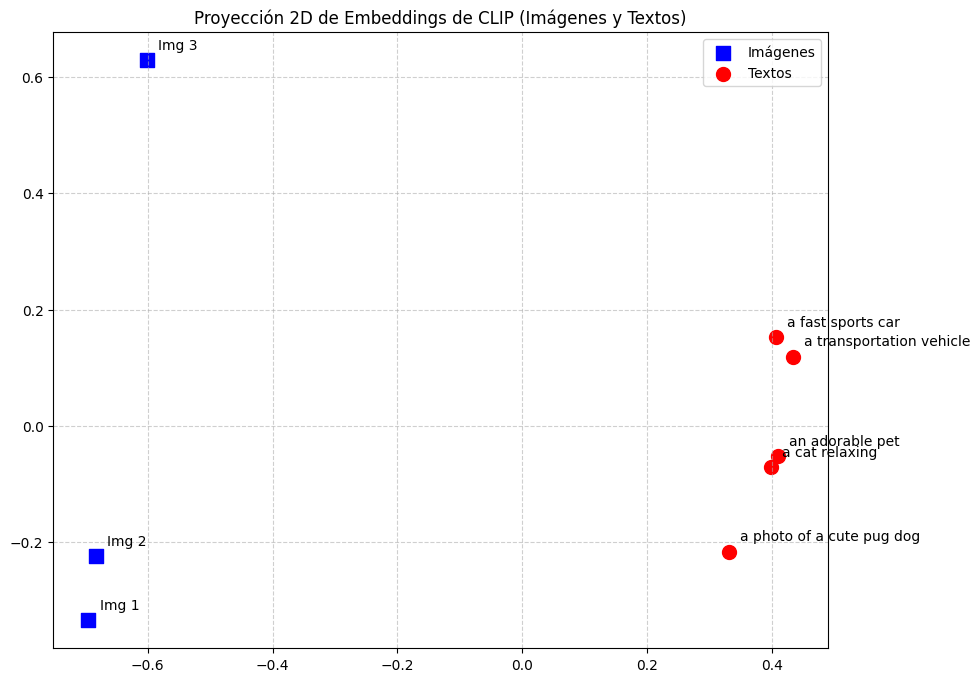

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Convertimos los tensores de PyTorch a arreglos de NumPy
img_emb_np = image_embeddings.cpu().numpy()
txt_emb_np = text_embeddings.cpu().numpy()

# 2. Concatenamos todos los vectores para proyectarlos en el mismo espacio 2D
all_embeddings = np.concatenate([img_emb_np, txt_emb_np], axis=0)

# 3. Aplicamos PCA para reducir de 512 a 2 dimensiones
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

# 4. Separamos nuevamente los puntos 2D de imágenes y textos
num_images = len(images)
img_2d = embeddings_2d[:num_images]
txt_2d = embeddings_2d[num_images:]

# 5. Configuramos la gráfica
plt.figure(figsize=(10, 8))

# Graficamos imágenes (Cuadrados azules)
plt.scatter(img_2d[:, 0], img_2d[:, 1], c='blue', marker='s', s=100, label='Imágenes')

# Graficamos textos (Círculos rojos)
plt.scatter(txt_2d[:, 0], txt_2d[:, 1], c='red', marker='o', s=100, label='Textos')

# 6. Añadimos etiquetas a cada punto para identificarlos
for i in range(num_images):
    plt.annotate(f"Img {i+1}", (img_2d[i, 0], img_2d[i, 1]), xytext=(8, 8), textcoords='offset points')

for i, txt in enumerate(texts):
    plt.annotate(txt, (txt_2d[i, 0], txt_2d[i, 1]), xytext=(8, 8), textcoords='offset points')

plt.title("Proyección 2D de Embeddings de CLIP (Imágenes y Textos)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

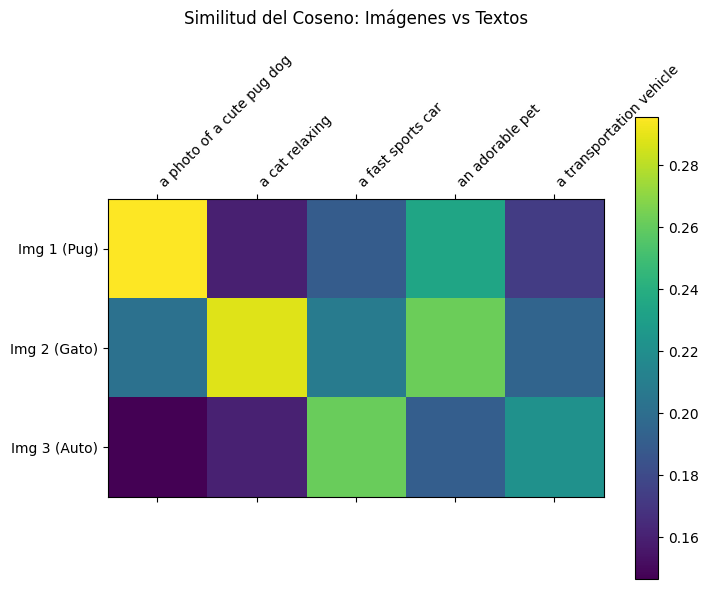

Resultados de búsqueda para Img 1 (Pug):
- a photo of a cute pug dog: 0.2954
- a cat relaxing: 0.1598
- a fast sports car: 0.1899
- an adorable pet: 0.2341
- a transportation vehicle: 0.1728


In [7]:
# 1. Calcular la similitud del coseno (producto punto de vectores normalizados)
# Multiplicamos la matriz de imágenes por la matriz transpuesta de textos
similarities = (image_embeddings @ text_embeddings.T).cpu().numpy()

# 2. Visualizar los resultados en un mapa de calor
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(similarities, cmap='viridis')
fig.colorbar(cax)

# 3. Configurar las etiquetas de los ejes
ax.set_xticks(np.arange(len(texts)))
ax.set_yticks(np.arange(len(images)))
ax.set_xticklabels(texts, rotation=45, ha="left")
ax.set_yticklabels([f"Img 1 (Pug)", f"Img 2 (Gato)", f"Img 3 (Auto)"])
ax.set_title("Similitud del Coseno: Imágenes vs Textos", pad=20)

plt.show()

# 4. Imprimir los valores exactos para la Img 1 como ejemplo
print("Resultados de búsqueda para Img 1 (Pug):")
for i, txt in enumerate(texts):
    print(f"- {txt}: {similarities[0, i]:.4f}")

Una vez comprobado matemáticamente que la similitud del coseno funciona de manera relativa (donde el valor más alto indica la mejor coincidencia angular), el paso final es estructurar esto como un verdadero sistema de **Recuperación de la Información**.

En un motor de búsqueda real, los valores absolutos de similitud pasan a un segundo plano; lo verdaderamente importante es el **ranking**. A continuación, definiremos una función que automatiza este proceso: tomará una imagen de consulta (*query*), calculará las distancias contra todos los documentos (textos) disponibles en nuestro espacio vectorial, ordenará los resultados de mayor a menor (`argsort`) y nos devolverá únicamente los $K$ resultados más relevantes (Top-K). 

Esto simula el comportamiento base de sistemas de recomendación y búsqueda multimodal modernos.

In [8]:
def buscar_textos_por_imagen(image_idx, top_k=3):
    """
    Simula un motor de búsqueda que recupera los textos más relevantes 
    para una imagen dada, utilizando similitud del coseno.
    """
    # 1. Extraemos el embedding de la imagen seleccionada y mantenemos sus 2 dimensiones (1, 512)
    img_emb = image_embeddings[image_idx].unsqueeze(0)
    
    # 2. Calculamos la similitud contra todos los embeddings de texto
    sims = (img_emb @ text_embeddings.T).squeeze(0).cpu().numpy()
    
    # 3. Ordenamos los índices de mayor a menor similitud (Ranking)
    top_indices = np.argsort(sims)[::-1][:top_k]
    
    # 4. Mostramos los resultados
    print(f"Resultados para la Img {image_idx + 1}:")
    print("-" * 45)
    for rank, idx in enumerate(top_indices):
        score = sims[idx]
        print(f"Top {rank + 1} | Score: {score:.4f} | Texto: '{texts[idx]}'")
    print("-" * 45)
    print()

# Ejecutamos pruebas simulando consultas de un usuario
buscar_textos_por_imagen(image_idx=0, top_k=3) # Búsqueda para el pug
buscar_textos_por_imagen(image_idx=1, top_k=3) # Búsqueda para el gato
buscar_textos_por_imagen(image_idx=2, top_k=3) # Búsqueda para el auto deportivo

Resultados para la Img 1:
---------------------------------------------
Top 1 | Score: 0.2954 | Texto: 'a photo of a cute pug dog'
Top 2 | Score: 0.2341 | Texto: 'an adorable pet'
Top 3 | Score: 0.1899 | Texto: 'a fast sports car'
---------------------------------------------

Resultados para la Img 2:
---------------------------------------------
Top 1 | Score: 0.2879 | Texto: 'a cat relaxing'
Top 2 | Score: 0.2619 | Texto: 'an adorable pet'
Top 3 | Score: 0.2085 | Texto: 'a fast sports car'
---------------------------------------------

Resultados para la Img 3:
---------------------------------------------
Top 1 | Score: 0.2612 | Texto: 'a fast sports car'
Top 2 | Score: 0.2221 | Texto: 'a transportation vehicle'
Top 3 | Score: 0.1912 | Texto: 'an adorable pet'
---------------------------------------------

